# LUAD Multimodal Imbalance Analysis — SurvITE + OGM-GE

This notebook mirrors `luad_imbalance_test.ipynb` but replaces the vanilla SurvITE
with **`ModalitySurvITE`** from `survite_ogmge.py`, which:

1. Keeps **separate encoders** for each modality (`clin`, `para`, `diag`, `omics`).
2. Applies **OGM-GE** on-the-fly: after every backward pass it computes a
   *contribution score* per encoder and re-scales its gradients so that
   dominant modalities are slowed down and weak ones catch up.
3. Optionally adds **Gaussian Enhancement** noise to restore gradient intensity.

We track the standard survival metrics (C-index, IBS) **plus** per-modality
contribution scores and gradient norms, which lets us visualise the imbalance
phenomenon and observe whether OGM-GE corrects it.

---
### OGM-GE method recap

Given $M$ modalities with contribution scores $\{s_m\}$:

$$\tilde{s}_m = \frac{e^{s_m}}{\sum_j e^{s_j}}, \qquad
k_m = 1 - \sigma(\tilde{s}_m - \bar{\tilde{s}})$$

Encoder $m$'s gradient is scaled by $k_m$ (dominant → small $k$, weak → close to 1).
GE then adds noise $\sim \mathcal{N}(0, \alpha\|g_m\|)$ to prevent collapse.

In [6]:
import os, sys, itertools
import numpy as np
import pandas as pd
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from collections import defaultdict
from tqdm.auto import tqdm
from lifelines.utils import concordance_index
from sksurv.metrics import integrated_brier_score

# ─── import our OGM-GE model ───────────────────────────────────────────────
sys.path.insert(0, '.')   # adjust if survite_ogmge.py lives elsewhere
from models.survite_ogmge import ModalitySurvITE

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cpu


In [7]:
# ──────────────────────────────────────────────────────────────────────────
# Configuration  (same as original notebook)
# ──────────────────────────────────────────────────────────────────────────
DATASET        = 'metabric'
TREAT_COL_NAME = 'Radio Therapy'
DATA_PATH      = f'data/{DATASET}'

network_settings = {
    'z_dim':       100,
    'h_dim1':      100,
    'h_dim2':      100,
    'num_layers1': 3,
    'num_layers2': 2,
    'active_fn':   'relu',
    'reg_scale':   0,
    'beta':        0.01,
    'ipm_term':    'wasserstein',
    'is_treat':    True,
    'is_smoothing': True,
    # Dimension projector: each modality's raw features are squeezed to this
    # size before the shared encoder.  Set to None to disable (original behaviour).
    # Typical values: 32 (more capacity) or 16 (more aggressive compression).
    'proj_dim':    32,
}

# OGM-GE hyper-parameters
OGM_ALPHA    = 0.1   # GE noise scale  (0.1 recommended for small modality gaps)
APPLY_GE     = True  # set False for pure OGM without noise
MODULATION_START = 0   # epoch at which modulation kicks in
MODULATION_END   = 100 # epoch at which modulation ends

In [8]:
# ──────────────────────────────────────────────────────────────────────────
# Data loading  (same as original, but returns per-modality arrays)
# ──────────────────────────────────────────────────────────────────────────
def load_data_multimodal(split_dir, modalities):
    """
    Returns
    -------
    X_dict : {mod: np.ndarray (N, d_mod)}   per-modality features
    T, E, A : 1-D arrays
    """
    X_dict = {}
    for mod in modalities:
        fp = os.path.join(split_dir, f'X_{mod}.csv')
        X_dict[mod] = pd.read_csv(fp, index_col='SAMPLE_ID').values

    X_treat = pd.read_csv(os.path.join(split_dir, 'X_treat.csv'), index_col='SAMPLE_ID')
    y_df    = pd.read_csv(os.path.join(split_dir, 'y.csv'))

    T = y_df['time'].values
    E = y_df['event'].values
    A = X_treat[TREAT_COL_NAME].values
    return X_dict, T, E, A

In [9]:
# ──────────────────────────────────────────────────────────────────────────
# Main training + evaluation function
# ──────────────────────────────────────────────────────────────────────────
def train_and_evaluate_ogmge(
        modalities,
        epochs=100,
        eval_interval=2,
        batch_size=256,
        t_max=50,
        seed=SEED,
        use_ogmge=True,        # set False for baseline (no OGM-GE)
        alpha=OGM_ALPHA,
        apply_ge=APPLY_GE,
        mod_start=MODULATION_START,
        mod_end=MODULATION_END,
):
    torch.manual_seed(seed)
    np.random.seed(seed)

    mod_name = ' + '.join(modalities)
    print(f'\n=== {mod_name} | OGM-GE={use_ogmge} ===')

    # ── 1. Load data ──────────────────────────────────────────────────────
    X_train_d, T_train, E_train, A_train = load_data_multimodal(f'{DATA_PATH}/train', modalities)
    X_test_d,  T_test,  E_test,  A_test  = load_data_multimodal(f'{DATA_PATH}/test',  modalities)

    # ── 2. Time discretisation ────────────────────────────────────────────
    max_time  = max(T_train.max(), T_test.max())
    time_bins = np.linspace(0, max_time, t_max + 1)

    def disc(T):
        return np.clip(np.digitize(T, time_bins) - 1, 0, t_max - 1)

    T_tr_disc = disc(T_train)
    T_te_disc = disc(T_test)

    T_tr_t = np.expand_dims(T_tr_disc, -1)
    E_tr_t = np.expand_dims(E_train,   -1)
    A_tr_t = np.expand_dims(A_train,   -1)
    A_te_t = np.expand_dims(A_test,    -1)

    # ── 3. sksurv structured arrays ───────────────────────────────────────
    def sksurv_arr(E, T):
        return np.array([(bool(e), t) for e, t in zip(E, T)],
                        dtype=[('event', '?'), ('time', '<f8')])

    train_sksurv = sksurv_arr(E_train, T_train)
    test_sksurv  = sksurv_arr(E_test,  T_test)

    min_t = T_test[E_test == 1].min() + 1e-5
    max_t = T_test.max() - 1e-5
    eval_times = time_bins[1:]
    eval_times = eval_times[(eval_times > min_t) & (eval_times < max_t)]
    eval_idx   = disc(eval_times)

    # ── 4. Model & optimiser ──────────────────────────────────────────────
    modality_dims = {m: X_train_d[m].shape[1] for m in modalities}
    model = ModalitySurvITE(modality_dims, t_max, network_settings, device=str(device))
    optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

    n_train = T_tr_t.shape[0]

    # ── 5. History ────────────────────────────────────────────────────────
    history = defaultdict(list)

    # ── 6. Training loop ──────────────────────────────────────────────────
    pbar = tqdm(range(1, epochs + 1), desc=mod_name)

    for epoch in pbar:
        model.train()
        idx = np.random.permutation(n_train)

        modulation_on = use_ogmge and (mod_start <= epoch <= mod_end) and (len(modalities) > 1)

        epoch_contrib  = defaultdict(list)
        epoch_gnorm_b  = defaultdict(list)
        epoch_gnorm_a  = defaultdict(list)
        epoch_k        = defaultdict(list)

        for start in range(0, n_train, batch_size):
            bi = idx[start:start + batch_size]
            xb = {m: X_train_d[m][bi] for m in modalities}
            yb = E_tr_t[bi]
            tb = T_tr_t[bi]
            ab = A_tr_t[bi]

            (loss_tot, loss_fact, loss_ipm,
             contrib, gnorm_b, gnorm_a, k_sc) = model.train_baseline_ogmge(
                optimizer, xb, yb, tb, ab,
                dropout_rate=0.2,
                alpha=alpha,
                apply_ge=apply_ge,
                modulation_active=modulation_on,
            )

            for m in modalities:
                epoch_contrib[m].append(contrib.get(m, 0.0))
                epoch_gnorm_b[m].append(gnorm_b.get(m, 0.0))
                epoch_gnorm_a[m].append(gnorm_a.get(m, 0.0))
                epoch_k[m].append(k_sc.get(m, 1.0))

        # Record per-epoch means
        for m in modalities:
            history[f'contrib_{m}'].append(np.mean(epoch_contrib[m]))
            history[f'gnorm_before_{m}'].append(np.mean(epoch_gnorm_b[m]))
            history[f'gnorm_after_{m}'].append(np.mean(epoch_gnorm_a[m]))
            history[f'k_{m}'].append(np.mean(epoch_k[m]))

        # ── Evaluation ────────────────────────────────────────────────────
        if epoch % eval_interval == 0:
            model.eval()
            xtest = {m: X_test_d[m] for m in modalities}
            surv1 = model.predict_survival_A1(xtest)
            surv0 = model.predict_survival_A0(xtest)
            surv_fact = A_te_t * surv1 + (1 - A_te_t) * surv0

            ci = concordance_index(T_test, surv_fact.sum(axis=1), E_test)

            try:
                ibs = integrated_brier_score(
                    train_sksurv, test_sksurv,
                    surv_fact[:, eval_idx], eval_times)
            except Exception:
                ibs = float('nan')

            history['epoch'].append(epoch)
            history['cidx'].append(ci)
            history['ibs'].append(ibs)
            pbar.set_postfix({'C-idx': f'{ci:.4f}', 'IBS': f'{ibs:.4f}'})

    # Also record imbalance metrics at eval epochs
    # (we store them at every epoch; caller can subset by history['epoch'])
    history['modalities'] = modalities
    return dict(history)

In [10]:
# ──────────────────────────────────────────────────────────────────────────
# Run experiments: baseline vs OGM-GE for every modality combination
# ──────────────────────────────────────────────────────────────────────────
ALL_MODALITIES = ['clin', 'para', 'diag', 'omics']

all_combos = []
for r in range(1, len(ALL_MODALITIES) + 1):
    all_combos.extend(itertools.combinations(ALL_MODALITIES, r))

results_baseline = {}
results_ogmge    = {}

for combo in all_combos:
    mods = list(combo)
    key  = ' + '.join(mods)

    results_baseline[key] = train_and_evaluate_ogmge(
        mods, epochs=100, use_ogmge=False)

    results_ogmge[key] = train_and_evaluate_ogmge(
        mods, epochs=100, use_ogmge=True)


=== clin | OGM-GE=False ===


clin: 100%|██████████| 100/100 [04:17<00:00,  2.57s/it, C-idx=0.5814, IBS=0.1847]



=== clin | OGM-GE=True ===


clin: 100%|██████████| 100/100 [03:58<00:00,  2.39s/it, C-idx=0.5814, IBS=0.1847]



=== para | OGM-GE=False ===


...

para + diag + omics: 100%|██████████| 100/100 [02:45<00:00,  1.65s/it, C-idx=0.5845, IBS=0.1804]



=== clin + para + diag + omics | OGM-GE=False ===


clin + para + diag + omics: 100%|██████████| 100/100 [02:43<00:00,  1.64s/it, C-idx=0.6141, IBS=0.2235]



=== clin + para + diag + omics | OGM-GE=True ===


clin + para + diag + omics: 100%|██████████| 100/100 [02:49<00:00,  1.69s/it, C-idx=0.6218, IBS=0.1794]


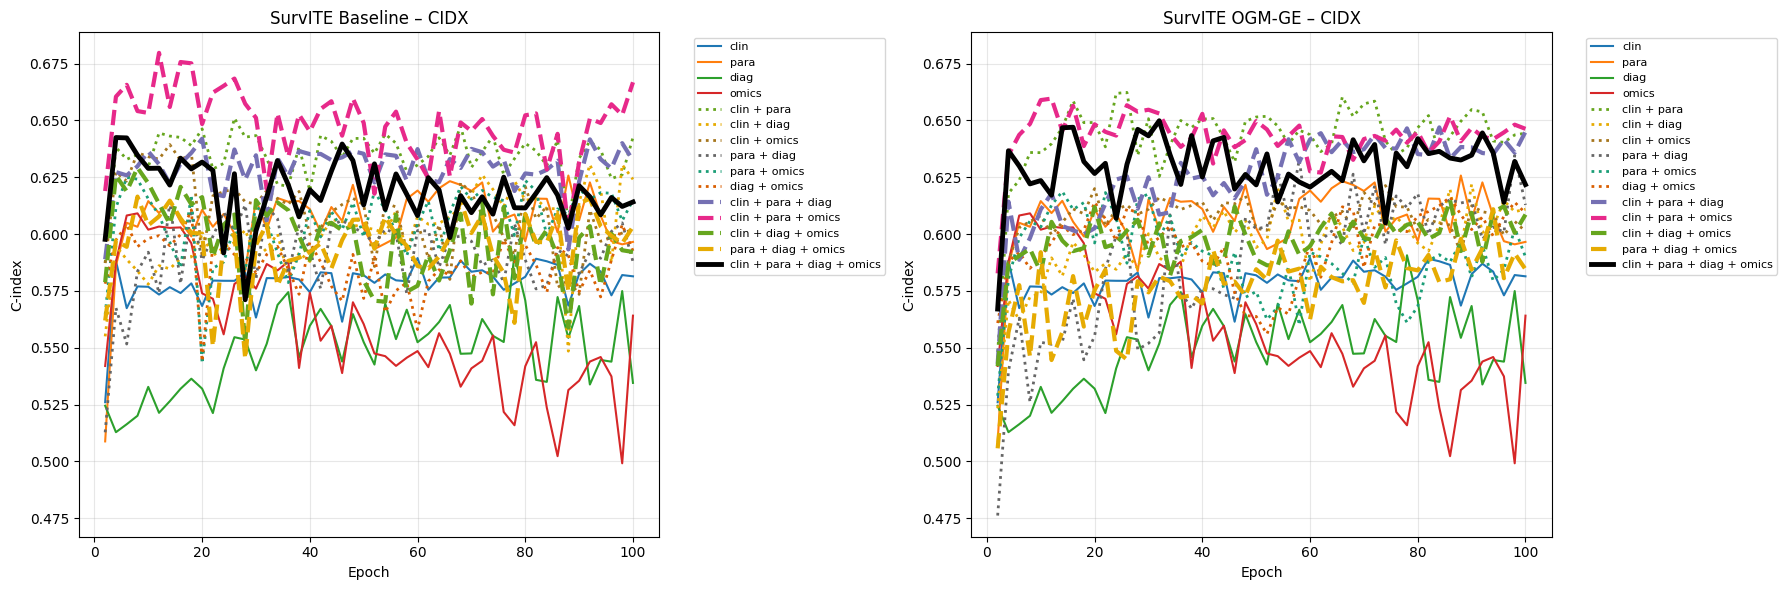

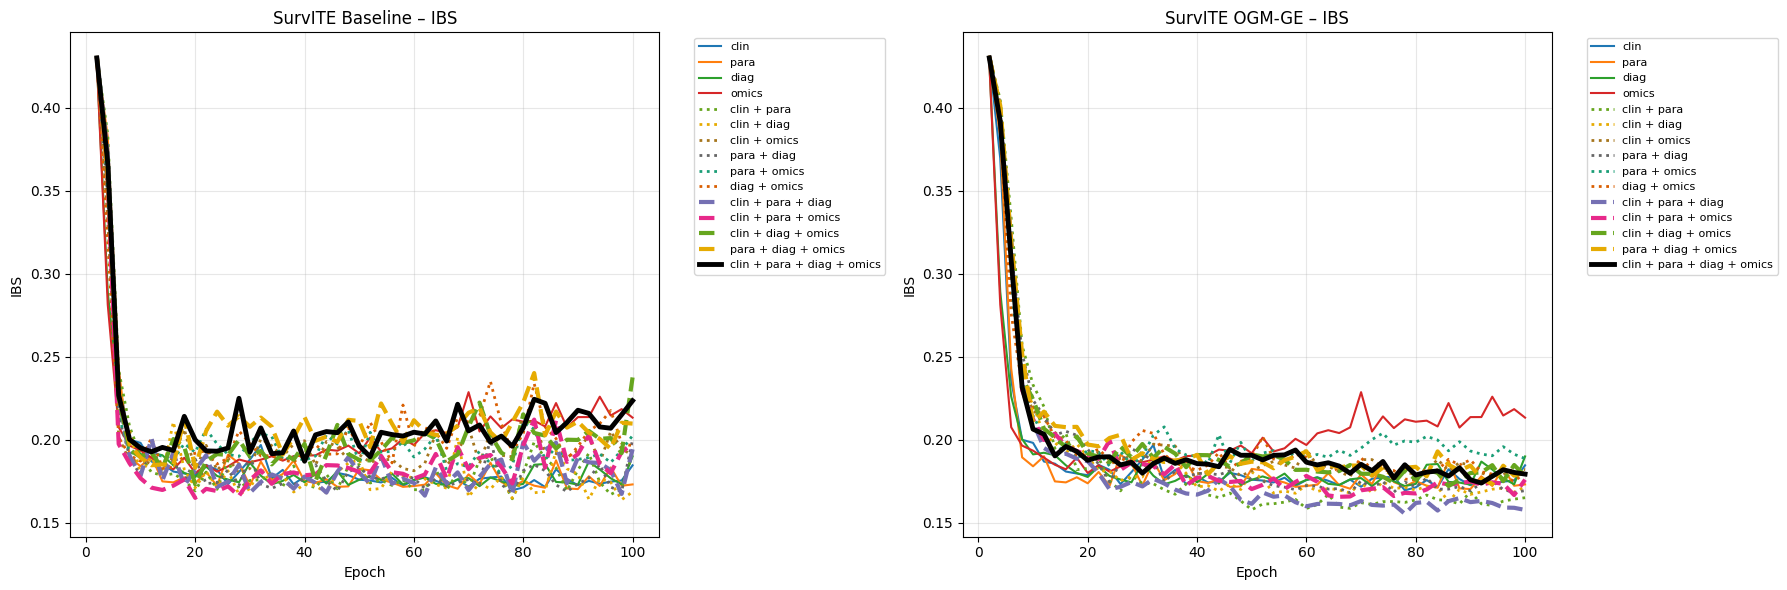

In [17]:
# ──────────────────────────────────────────────────────────────────────────
# Plotting helpers  (same style as original notebook)
# ──────────────────────────────────────────────────────────────────────────
SINGLE_COLORS = {'clin': 'C0', 'para': 'C1', 'diag': 'C2', 'omics': 'C3'}
PALETTE       = sns.color_palette('Dark2', n_colors=15)

LINE_STYLES = {
    0: {'ls': '-',  'lw': 1.5},
    1: {'ls': ':',  'lw': 2},
    2: {'ls': '--', 'lw': 3},
    3: {'ls': '-',  'lw': 3.5, 'color': 'black'},
}

def _plot_metric(results_dict, metric, mode='all', ax=None, title_suffix=''):
    y_label = {'cidx': 'C-index', 'ibs': 'IBS'}[metric]
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 6))
    skip_plus_counts = []
    if mode == 'single':   skip_plus_counts = [1, 2, 3]
    elif mode == 'pair':   skip_plus_counts = [0, 2, 3]
    elif mode == 'tri':    skip_plus_counts = [0, 1, 3]
    elif mode == 'quad':   skip_plus_counts = [0, 1, 2]
    # 'all' → nothing skipped

    for i, (key, hist) in enumerate(results_dict.items()):
        plus_cnt = key.count('+')
        if plus_cnt in skip_plus_counts:
            continue
        style = LINE_STYLES[plus_cnt]
        color = SINGLE_COLORS.get(key, style.get('color', PALETTE[i % len(PALETTE)]))
        ax.plot(hist['epoch'], hist[metric], label=key,
                color=color, lw=style['lw'], ls=style['ls'])

    ax.set_xlabel('Epoch'); ax.set_ylabel(y_label)
    ax.set_title(f'SurvITE {title_suffix} – {metric.upper()}')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    ax.grid(True, alpha=0.3)
    return ax

# Side-by-side: Baseline vs OGM-GE
def plot_comparison(metric='cidx', mode='all'):
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    _plot_metric(results_baseline, metric, mode, ax=axes[0], title_suffix='Baseline')
    _plot_metric(results_ogmge,    metric, mode, ax=axes[1], title_suffix='OGM-GE')

    # Sync y-axis range across both panels so the plots are directly comparable
    ymin = min(ax.get_ylim()[0] for ax in axes)
    ymax = max(ax.get_ylim()[1] for ax in axes)
    for ax in axes:
        ax.set_ylim(ymin, ymax)

    plt.tight_layout()
    plt.show()

plot_comparison('cidx', 'all')
plot_comparison('ibs',  'all')

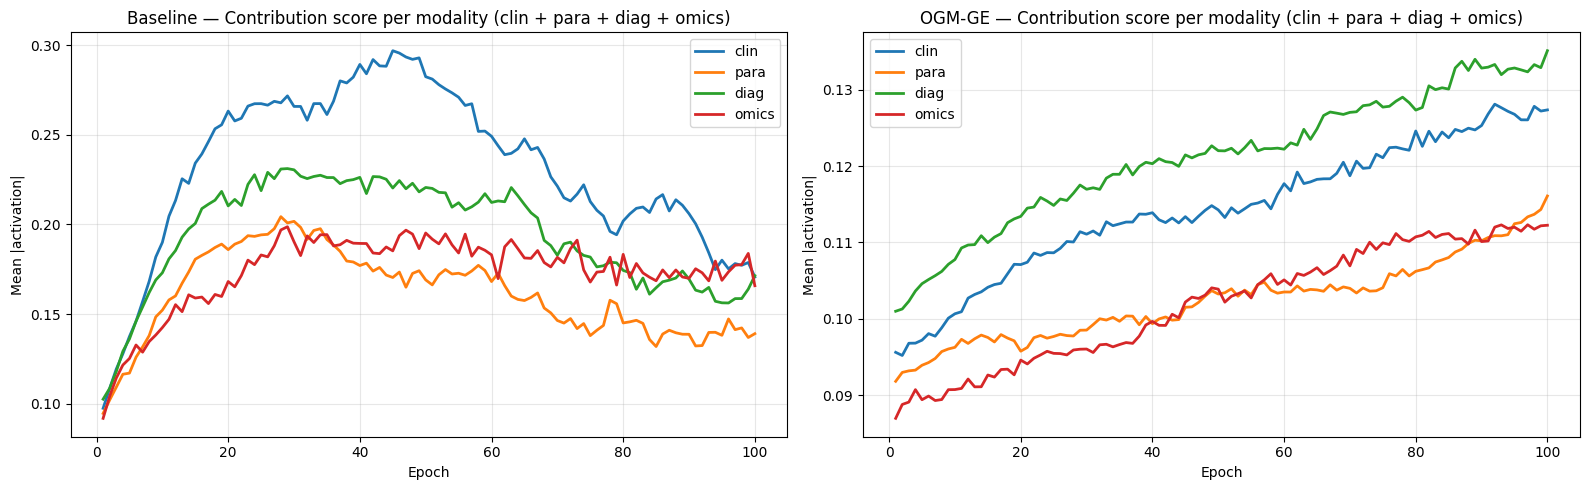

In [12]:
# ──────────────────────────────────────────────────────────────────────────
# Imbalance visualisation 1 – per-modality contribution over training
# For the full 4-modality combo
# ──────────────────────────────────────────────────────────────────────────
FULL_KEY = 'clin + para + diag + omics'

def plot_imbalance_contributions(key=FULL_KEY):
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    for ax, (tag, res) in zip(axes, [('Baseline', results_baseline),
                                      ('OGM-GE',   results_ogmge)]):
        hist = res[key]
        mods = hist['modalities']
        epochs_all = range(1, len(hist[f'contrib_{mods[0]}']) + 1)
        for m in mods:
            ax.plot(epochs_all, hist[f'contrib_{m}'],
                    label=m, color=SINGLE_COLORS[m], lw=2)
        ax.set_title(f'{tag} — Contribution score per modality ({key})')
        ax.set_xlabel('Epoch'); ax.set_ylabel('Mean |activation|')
        ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_imbalance_contributions()

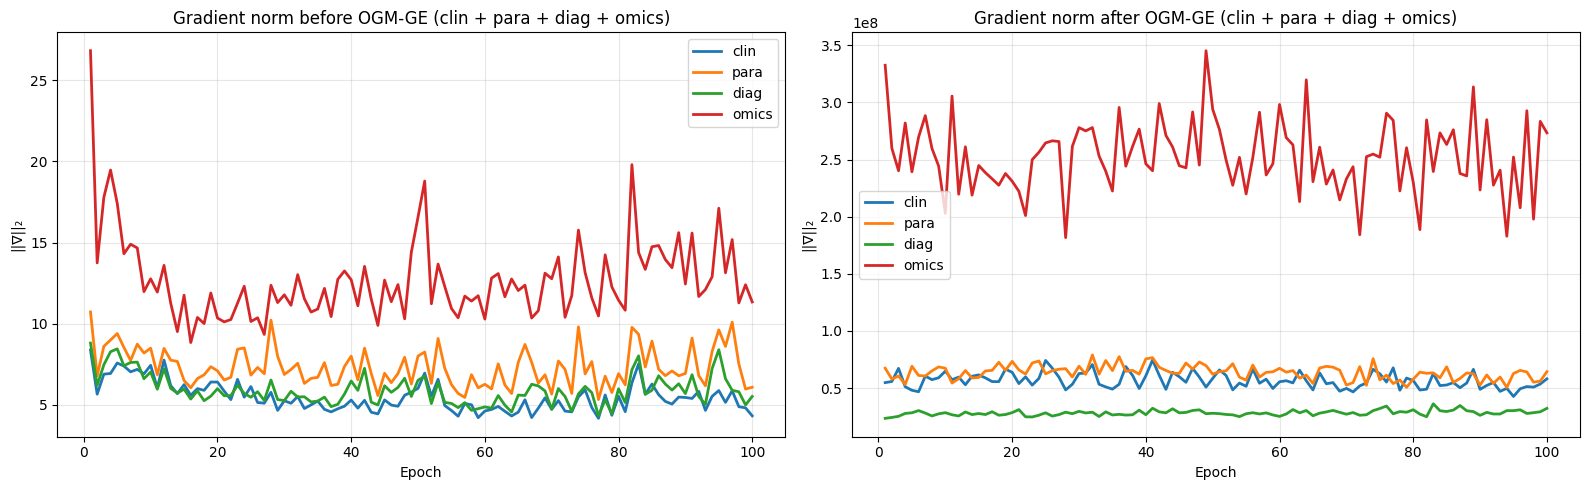

In [13]:
# ──────────────────────────────────────────────────────────────────────────
# Imbalance visualisation 2 – gradient norms before vs after OGM-GE
# ──────────────────────────────────────────────────────────────────────────
def plot_gradient_norms(key=FULL_KEY):
    hist = results_ogmge[key]
    mods = hist['modalities']
    epochs_all = range(1, len(hist[f'gnorm_before_{mods[0]}']) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    for ax, stage in zip(axes, ['before', 'after']):
        for m in mods:
            ax.plot(epochs_all, hist[f'gnorm_{stage}_{m}'],
                    label=m, color=SINGLE_COLORS[m], lw=2)
        ax.set_title(f'Gradient norm {stage} OGM-GE ({key})')
        ax.set_xlabel('Epoch'); ax.set_ylabel('||∇||₂')
        ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_gradient_norms()

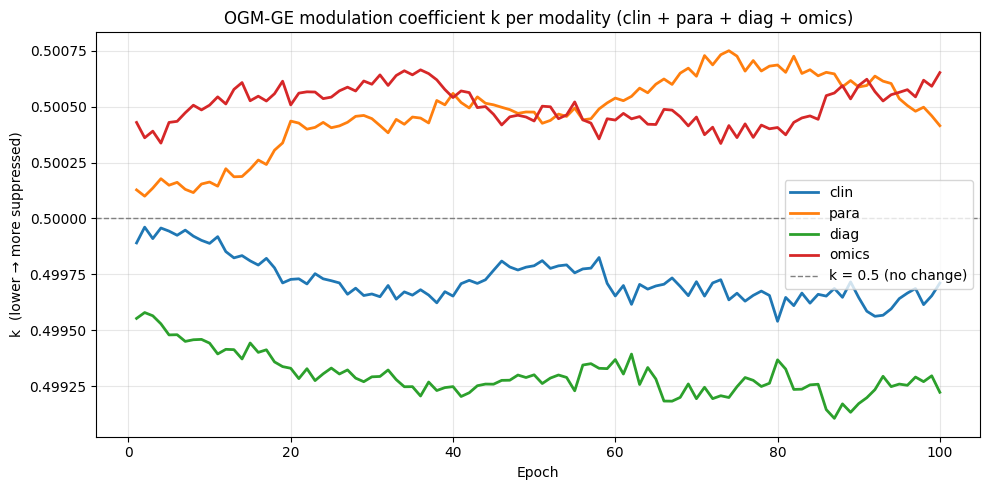

In [14]:
# ──────────────────────────────────────────────────────────────────────────
# Imbalance visualisation 3 – modulation coefficient k per modality
# k < 0.5 → dominant modality being slowed down
# k > 0.5 → weak modality getting a boost
# ──────────────────────────────────────────────────────────────────────────
def plot_k_scores(key=FULL_KEY):
    hist = results_ogmge[key]
    mods = hist['modalities']
    if len(mods) < 2:
        print('k-scores are only meaningful for multi-modal runs.')
        return
    epochs_all = range(1, len(hist[f'k_{mods[0]}']) + 1)

    plt.figure(figsize=(10, 5))
    for m in mods:
        plt.plot(epochs_all, hist[f'k_{m}'], label=m,
                 color=SINGLE_COLORS[m], lw=2)
    plt.axhline(0.5, color='grey', ls='--', lw=1, label='k = 0.5 (no change)')
    plt.title(f'OGM-GE modulation coefficient k per modality ({key})')
    plt.xlabel('Epoch'); plt.ylabel('k  (lower → more suppressed)')
    plt.legend(); plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_k_scores()

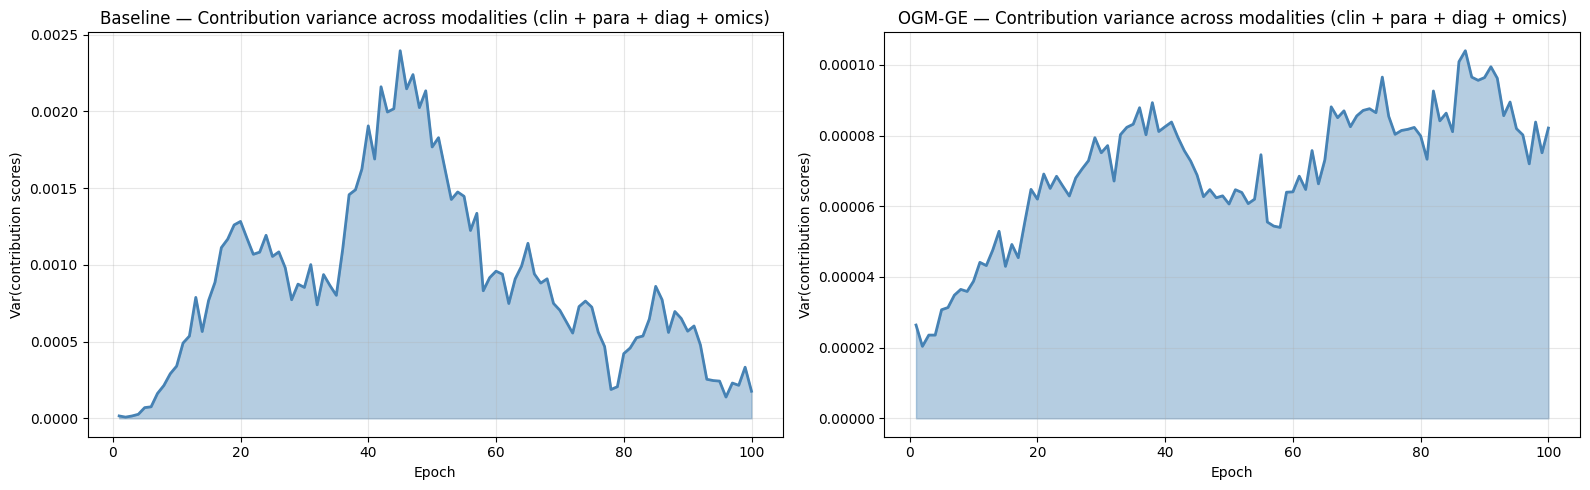

In [15]:
# ──────────────────────────────────────────────────────────────────────────
# Imbalance visualisation 4 – Contribution variance (imbalance summary)
# Lower variance = more balanced learning across modalities
# ──────────────────────────────────────────────────────────────────────────
def plot_contribution_variance(key=FULL_KEY):
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    for ax, (tag, res) in zip(axes, [('Baseline', results_baseline),
                                      ('OGM-GE',   results_ogmge)]):
        hist = res[key]
        mods = hist['modalities']
        n_ep = len(hist[f'contrib_{mods[0]}'])
        epochs_all = range(1, n_ep + 1)
        stack = np.stack([hist[f'contrib_{m}'] for m in mods], axis=0)  # (M, epochs)
        variance = stack.var(axis=0)  # variance across modalities per epoch
        ax.fill_between(epochs_all, 0, variance, alpha=0.4, color='steelblue')
        ax.plot(epochs_all, variance, color='steelblue', lw=2)
        ax.set_title(f'{tag} — Contribution variance across modalities ({key})')
        ax.set_xlabel('Epoch'); ax.set_ylabel('Var(contribution scores)')
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_contribution_variance()

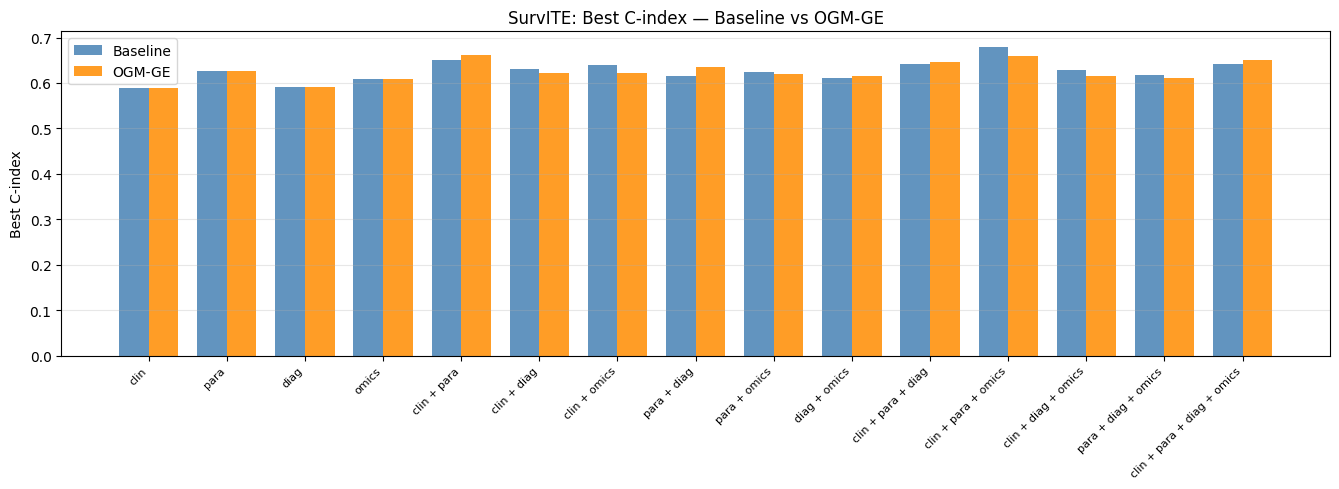

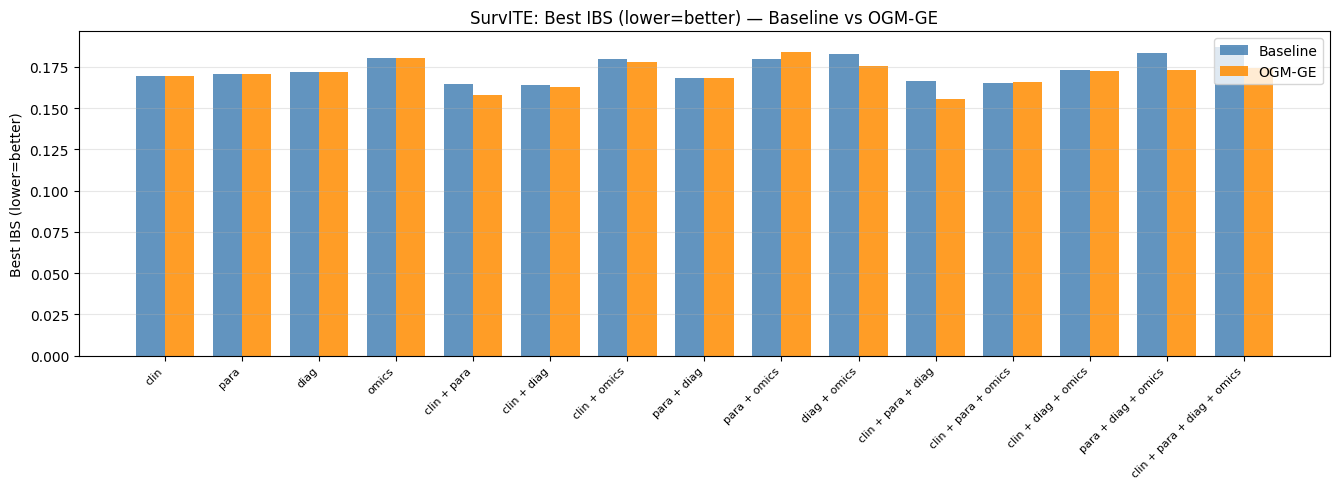

In [16]:
# ──────────────────────────────────────────────────────────────────────────
# Imbalance visualisation 5 – final performance bar chart
# Best C-index per modality combination, Baseline vs OGM-GE
# ──────────────────────────────────────────────────────────────────────────
def plot_performance_bars(metric='cidx'):
    y_label = {'cidx': 'Best C-index', 'ibs': 'Best IBS (lower=better)'}[metric]
    keys = list(results_baseline.keys())

    def best(res, key):
        vals = [v for v in res[key][metric] if not np.isnan(v)]
        if not vals: return float('nan')
        return max(vals) if metric == 'cidx' else min(vals)

    base_vals = [best(results_baseline, k) for k in keys]
    ogm_vals  = [best(results_ogmge,    k) for k in keys]

    x = np.arange(len(keys))
    w = 0.38
    fig, ax = plt.subplots(figsize=(max(10, len(keys) * 0.9), 5))
    ax.bar(x - w/2, base_vals, w, label='Baseline', color='steelblue', alpha=0.85)
    ax.bar(x + w/2, ogm_vals,  w, label='OGM-GE',   color='darkorange', alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(keys, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel(y_label)
    ax.set_title(f'SurvITE: {y_label} — Baseline vs OGM-GE')
    ax.legend(); ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()

plot_performance_bars('cidx')
plot_performance_bars('ibs')